# Results figure

Builds the summary figure used in the README: the path to the PTB-XL benchmark
across training regimes for both architectures, and the per-class AUROC of the
ensemble. Numbers are the test-fold (fold 10) macro-AUROC reported in the
README.

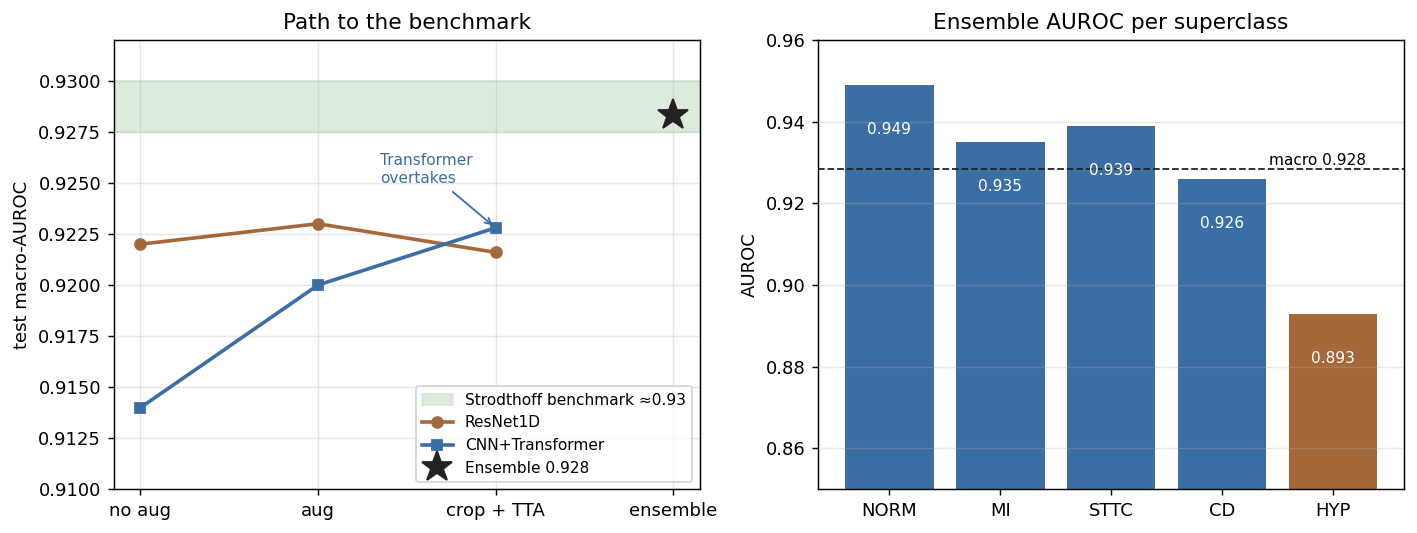

saved docs/results.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

CLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]
stages = ["no aug", "aug", "crop + TTA"]
resnet = [0.922, 0.923, 0.9216]
transformer = [0.914, 0.920, 0.9228]
ensemble = 0.9283
benchmark = 0.928
ens_per_class = [0.949, 0.935, 0.939, 0.926, 0.893]

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

x = np.arange(len(stages))
ax1.axhspan(benchmark - 0.0005, 0.930, color="#cfe3cf", alpha=0.7,
            label="Strodthoff benchmark ≈0.93")
ax1.plot(x, resnet, "o-", color="#a5683b", lw=2, label="ResNet1D")
ax1.plot(x, transformer, "s-", color="#3b6ea5", lw=2, label="CNN+Transformer")
ax1.plot(len(stages), ensemble, "*", color="#222", ms=18, label=f"Ensemble {ensemble:.3f}")
ax1.annotate("Transformer\novertakes", (2, transformer[2]), (1.35, 0.925),
             fontsize=8.5, color="#3b6ea5",
             arrowprops=dict(arrowstyle="->", color="#3b6ea5"))
ax1.set_xticks(list(x) + [len(stages)], stages + ["ensemble"])
ax1.set_ylabel("test macro-AUROC"); ax1.set_ylim(0.910, 0.932)
ax1.set_title("Path to the benchmark"); ax1.grid(alpha=0.3)
ax1.legend(loc="lower right", fontsize=8.5)

colors = ["#3b6ea5"] * 4 + ["#a5683b"]
bars = ax2.bar(CLASSES, ens_per_class, color=colors)
ax2.axhline(ensemble, ls="--", color="#222", lw=1)
ax2.text(4.3, ensemble + 0.001, f"macro {ensemble:.3f}", ha="right", fontsize=8.5)
for b, v in zip(bars, ens_per_class):
    ax2.text(b.get_x() + b.get_width()/2, v - 0.012, f"{v:.3f}", ha="center",
             color="white", fontsize=8.5)
ax2.set_ylim(0.85, 0.96); ax2.set_ylabel("AUROC")
ax2.set_title("Ensemble AUROC per superclass"); ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
Path("../docs").mkdir(exist_ok=True)
fig.savefig("../docs/results.png", bbox_inches="tight", dpi=130)
plt.show()
print("saved docs/results.png")

HYP (12% prevalence, amplitude-defined) is the hardest superclass; the ensemble of the two architectures reaches the benchmark level.